# Práctica adicional 10a — k-NN de clasificación sobre un problema de estructura lineal

El laboratorio de la clase construyó k-NN desde cero sobre dos anillos concéntricos: un
problema **elegido para que ninguna frontera lineal lo resuelva**, y donde por lo tanto un
método local gana por definición. Esta práctica hace la pregunta opuesta y sobre datos de
otra naturaleza: **cuando la estructura del problema sí es lineal, ¿qué le pasa a k-NN?**

El conjunto es el de riesgo crediticio, ya conocido: $4000$ solicitudes con nueve atributos
numéricos, un atributo categórico y una respuesta binaria. No tiene faltantes y no necesita
más tratamiento previo que el escalado, de modo que todo el peso de la práctica queda sobre
las tres decisiones que importan acá.

1. **La codificación del atributo categórico.** La distancia Euclídea está definida sobre
   $\mathbb{R}^p$; un historial crediticio no lo está. Las notas dejan el punto afuera
   explícitamente, y la sección 1 lo resuelve: cómo se codifica un atributo nominal para
   que la distancia entre dos niveles cualesquiera no afirme nada que los datos no digan.
2. **El tamaño del vecindario**, elegido por validación cruzada sobre el conjunto de
   entrenamiento.
3. **La comparación contra una línea base lineal**: la regresión logística, ajustada sobre
   exactamente la misma preparación, para que la comparación mida el método y no el
   tratamiento previo.

Hay **tres ejercicios**. Las celdas que contienen `raise NotImplementedError()` deben
completarse; el resto es andamiaje y se ejecuta sin modificar. La conclusión final la
escribe el estudiante: el entregable de esta práctica es esa conclusión, justificada con
las cifras que las celdas producen.

> **Notación.** $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n}$ el conjunto de
> entrenamiento, $\mathbf{x}_0$ el punto de consulta, $k$ el tamaño del vecindario,
> $d_2$ la distancia Euclídea, $\pi_j$ la proporción del nivel $j$ de un atributo
> categórico y $m$ su cantidad de niveles.

## 0. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({"figure.figsize": (8, 3.6), "axes.grid": True, "grid.alpha": 0.3})
np.set_printoptions(precision=4, suppress=True)

# Paleta del curso
AZUL, TURQUESA, NARANJA = "#19326E", "#50ACB0", "#CD742A"
VIOLETA, OLIVA, AZUL_CLARO = "#A3477F", "#89A943", "#4294CC"

SEMILLA = 42

In [2]:
from pathlib import Path
import urllib.request

# Carga de datos del curso. No hace falta modificar nada.
URL_DATOS = "https://raw.githubusercontent.com/gustavovazquez/datasets/main/"


def ruta_del_dato(nombre: str) -> str:
    """Devuelve algo que `pd.read_csv` pueda leer, este donde este el notebook.

    Busca el archivo junto al notebook y en las carpetas `data/` de hasta tres
    niveles superiores; si no esta, usa la copia publicada en linea; y si
    tampoco hay red, en Colab ofrece subirlo a mano.
    """
    candidatas = [Path(nombre), Path("data") / nombre]
    for arriba in ("..", "../..", "../../.."):
        candidatas += [Path(arriba) / nombre, Path(arriba) / "data" / nombre]
    for ruta in candidatas:
        if ruta.exists():
            print(f"Cargado desde {ruta}")
            return str(ruta)

    url = URL_DATOS + nombre
    try:
        urllib.request.urlopen(url, timeout=15)
        print(f"No esta en disco; se descarga de {url}")
        return url
    except Exception:
        pass

    try:
        from google.colab import files  # type: ignore
    except ImportError:
        raise FileNotFoundError(
            f"No se encontro {nombre}. Dejarlo en una carpeta 'data/' junto al notebook.")

    print(f"Falta {nombre}: seleccionar el archivo para subirlo.")
    subidos = files.upload()
    destino = Path("data")
    destino.mkdir(exist_ok=True)
    ruta = destino / nombre
    ruta.write_bytes(subidos[nombre])
    return str(ruta)

### Los datos

`riesgo_credito.csv`, $4000 \times 12$. Cada fila es una solicitud de crédito ya resuelta.

| Columna | Tipo | Qué es |
|---|---|---|
| `id_solicitud` | identificador | **No es un atributo.** Se descarta |
| `edad_anios`, `antiguedad_laboral_anios`, `ingreso_mensual_usd`, `monto_solicitado_usd`, `plazo_meses`, `cuota_mensual_usd`, `cuota_ingreso`, `consultas_buro_12m` | numéricos | Escalas muy dispares: la cuota sobre el ingreso es una fracción y el ingreso está en dólares |
| `tiene_garantia` | binario $0/1$ | Ya es una indicadora |
| `historial_crediticio` | **categórico**, tres niveles | `al día`, `sin historial`, `con atrasos` |
| `incumplio` | respuesta binaria | $1$ si la solicitud terminó en incumplimiento |

El conjunto **no tiene faltantes**: está limpio a propósito, porque lo que se ejercita acá
no es el tratamiento previo sino la métrica.

> **Antes de ejecutar.** El archivo se descarga de webasignatura y corresponde dejarlo en
> una carpeta `data/` junto al notebook. En Colab, si el archivo no está, la celda de carga
> ofrece subirlo.

In [3]:
credito = pd.read_csv(ruta_del_dato("riesgo_credito.csv"))

RESPUESTA = "incumplio"
IDENTIFICADOR = "id_solicitud"

y = credito[RESPUESTA].to_numpy(dtype=int)
X = credito.drop(columns=[IDENTIFICADOR, RESPUESTA])

X_ent, X_pru, y_ent, y_pru = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA, stratify=y)

print(f"conjunto completo : {X.shape[0]} solicitudes, {X.shape[1]} atributos")
print(f"entrenamiento     : {len(y_ent)}   incumplimiento {y_ent.mean():.4f}")
print(f"prueba            : {len(y_pru)}   incumplimiento {y_pru.mean():.4f}")
print(f"faltantes         : {int(credito.isna().sum().sum())}")
print()
print("niveles de historial_crediticio:")
print(X["historial_crediticio"].value_counts(normalize=True).round(4).to_string())
print()
print("escalas de los atributos numéricos:")
print(X.select_dtypes("number").agg(["mean", "std"]).T.round(2).to_string())

Cargado desde data/riesgo_credito.csv
conjunto completo : 4000 solicitudes, 10 atributos
entrenamiento     : 3000   incumplimiento 0.2183
prueba            : 1000   incumplimiento 0.2180
faltantes         : 0

niveles de historial_crediticio:
historial_crediticio
al dia           0.4988
sin historial    0.3015
con atrasos      0.1998

escalas de los atributos numéricos:
                             mean       std
edad_anios                  37.90     10.16
antiguedad_laboral_anios     3.67      3.67
ingreso_mensual_usd       1801.27   1219.19
monto_solicitado_usd      9597.84  10993.12
plazo_meses                 30.61     14.28
cuota_mensual_usd          425.54    435.91
cuota_ingreso                0.24      0.16
consultas_buro_12m           1.43      1.58
tiene_garantia               0.33      0.47


---

# 1. Un atributo categórico dentro de una distancia

Las notas de la clase dejan este punto explícitamente afuera. La distancia Euclídea está
definida sobre $\mathbb{R}^p$, y `historial_crediticio` no toma valores en $\mathbb{R}$.
Antes de que k-NN pueda mirar quién está cerca hay que decidir **qué vector le corresponde
a cada nivel**, y esa decisión no es un trámite: entra dentro de la suma de la distancia y
determina quiénes son vecinos.

## Por qué un código entero no sirve

La tentación es reemplazar `al día`, `sin historial` y `con atrasos` por $0$, $1$ y $2$, y
tratar la columna como una más. Esa codificación **afirma dos cosas que nadie verificó**:

- que los tres niveles están **ordenados**, y en ese orden;
- que las **distancias entre niveles** son las que dicen los números, de modo que
  `al día` queda a distancia $2$ de `con atrasos` y a distancia $1$ de `sin historial`;
  al cuadrado, cuatro veces más lejos.

La segunda es la más grave, porque sobrevive aunque el orden sea el correcto: el código
impone un **espaciamiento uniforme** entre niveles consecutivos que ningún dato respalda.
Y en un atributo sin orden alguno —el área de una empresa, la planta de una máquina, el
país de origen— ni siquiera la primera afirmación tiene sentido.

## La codificación indicadora

`OneHotEncoder` reemplaza la columna por $m$ columnas $0/1$, una por nivel, con un único
$1$ por fila. Sobre ese bloque de $m$ columnas, la distancia al cuadrado entre dos
observaciones $a$ y $b$ vale entonces

$$
\sum_{j=1}^{m}\bigl(x_{aj}-x_{bj}\bigr)^{2}
=\begin{cases}
0, & \text{si } a \text{ y } b \text{ comparten nivel},\\[2pt]
2, & \text{si no},
\end{cases}
$$

porque dos filas con niveles distintos difieren en exactamente dos columnas, en una unidad
cada una. Es una **distancia de Hamming multiplicada por dos**: todos los pares de niveles
distintos quedan a la misma distancia entre sí, que es precisamente lo que significa que un
atributo sea nominal. La codificación no inventa ningún orden porque no puede.

De ahí salen tres consecuencias operativas, y las tres son propias de k-NN:

1. **No se descarta ningún nivel.** En un modelo lineal se elimina una columna
   (`drop="first"`) para evitar la colinealidad perfecta con el intercepto. En una distancia
   eso rompe la simetría: el nivel de referencia pasa a estar a distancia al cuadrado $1$ de
   los demás, mientras los demás quedan a $2$ entre sí, y el nivel de referencia se vuelve
   artificialmente **el más parecido a todo**. Con dos niveles no hay problema —una sola
   columna $0/1$ ya es simétrica—, y por eso `tiene_garantia` no necesita tratamiento.
2. **Las indicadoras no se estandarizan.** Estandarizar divide cada columna por su desvío,
   que depende de la frecuencia del nivel. Con eso **la equidistancia se rompe**: dos
   niveles poco frecuentes quedan más lejos entre sí que dos frecuentes, sin que nada en
   los datos afirme que se parecen menos. La celda de la sección siguiente lo muestra.
3. **Cada nivel es una columna más.** Con muchos niveles el atributo agrega muchas
   dimensiones y, además, casi todos los pares de observaciones terminan difiriendo de
   nivel: la distancia entre casi todo par vale lo mismo y el atributo deja de distinguir.
   La clase siguiente retoma el fenómeno.

## Cómo se hace en `scikit-learn`

Las decisiones anteriores no se programan a mano: se expresan como argumentos de dos clases
de la biblioteca. Conviene conocer cuáles, porque **los valores predeterminados no son los
que convienen en una distancia**.

### `OneHotEncoder` — la codificación indicadora

| Argumento | Valor | Qué hace, y qué significa acá |
|---|---|---|
| `drop` | `None` (predeterminado) | Una columna por nivel. **Es el valor que corresponde en k-NN**: deja a la misma distancia a todo par de niveles distintos |
| | `"first"` | Descarta el primer nivel. Es lo obligatorio en un modelo lineal, para evitar la colinealidad con el intercepto, y lo que rompe la simetría de la distancia |
| | `"if_binary"` | Descarta un nivel solo cuando el atributo tiene dos. Inocuo en una distancia: con dos niveles, una sola indicadora ya es simétrica |
| `sparse_output` | `False` | Devuelve un `ndarray` denso en lugar de una matriz rala. Con pocos niveles no hay nada que ahorrar, y el array denso se puede imprimir e inspeccionar |
| `handle_unknown` | `"ignore"` | Un nivel que no apareció al ajustar produce una fila de ceros en vez de un error. Con validación cruzada y niveles poco frecuentes, es lo que evita que una partición falle |
| `min_frequency`, `max_categories` | enteros | Agrupan los niveles raros en una categoría `infrequent_sklearn`. Es la herramienta para el problema de alta cardinalidad del punto 3 |

Después de ajustar, `codificador.categories_` devuelve el orden en que quedaron los niveles y
`codificador.get_feature_names_out()`, los nombres de las columnas producidas. **Conviene
mirar ambos**: el orden lo fija el ajuste, no el `DataFrame`, y de él depende cuál es el
nivel que `drop="first"` descarta.

> **`OrdinalEncoder` no es la alternativa.** Produce exactamente el código entero
> $0,1,2,\dots$ discutido arriba, con el orden alfabético de los niveles si no se le
> especifica otro. Es la herramienta correcta para un atributo genuinamente ordinal cuyo
> espaciamiento se quiera afirmar, y la incorrecta para uno nominal.

### `ColumnTransformer` — un transformador distinto para cada bloque

Los atributos numéricos y los categóricos necesitan tratamientos distintos, y
`ColumnTransformer` es lo que permite aplicarlos sobre el mismo `DataFrame` y concatenar el
resultado. Se construye con una lista de tripletas `(nombre, transformador, columnas)`.

Dos detalles que importan:

- **`remainder="drop"` es el valor predeterminado**: toda columna que no figure en ninguna
  tripleta desaparece sin aviso. Es cómodo —así se descarta el identificador— y peligroso en
  la misma medida, y por eso la verificación del ejercicio cuenta las columnas de salida.
- **El orden de las columnas de salida es el de las tripletas**, no el del `DataFrame`.
  `get_feature_names_out()` lo devuelve, con el nombre de la tripleta como prefijo.

### `Pipeline` — para que el ajuste ocurra donde debe

El `ColumnTransformer` encadenado con el modelo dentro de un `Pipeline` se ajusta **una vez
por partición** de la validación cruzada, con los datos de entrenamiento de esa partición
solamente. Es lo que evita que la media y el desvío se estimen sobre observaciones que
después se usan para evaluar, que en k-NN significa dejar que el conjunto de validación
participe de definir quiénes son vecinos.

La celda siguiente muestra el codificador aislado sobre una tabla mínima de cuatro filas,
con las tres variantes, y la matriz de distancias al cuadrado que produce cada una. Es
donde se ve, sobre números concretos, cuál de las tres conserva la equidistancia.

In [4]:
# El codificador aislado, sobre una tabla mínima donde todo se puede seguir a mano
juguete = pd.DataFrame({"historial": ["al dia", "sin historial", "con atrasos", "al dia"]})


def distancias_al_cuadrado(Z: np.ndarray) -> np.ndarray:
    """Matriz de distancias al cuadrado entre todas las filas de Z."""
    return ((Z[:, None, :] - Z[None, :, :]) ** 2).sum(axis=2)


variantes_juguete = [
    ("drop=None — una columna por nivel",
     OneHotEncoder(sparse_output=False)),
    ("drop=\"first\" — el primer nivel se descarta",
     OneHotEncoder(drop="first", sparse_output=False)),
    ("drop=None, con las indicadoras estandarizadas",
     Pipeline([("ohe", OneHotEncoder(sparse_output=False)), ("esc", StandardScaler())])),
]

etiquetas = juguete["historial"].to_numpy()
for titulo, transformador in variantes_juguete:
    Z = transformador.fit_transform(juguete)
    columnas = [c.replace("historial_", "") for c in transformador.get_feature_names_out()]
    print(f"--- {titulo} ---")
    print(pd.DataFrame(Z, index=etiquetas, columns=columnas).round(3).to_string())
    print("distancias al cuadrado entre las cuatro filas:")
    print(pd.DataFrame(distancias_al_cuadrado(Z),
                       index=etiquetas, columns=etiquetas).round(3).to_string())
    print()

print("Con drop=None todo par de niveles distintos vale 2 y todo par igual vale 0.")
print("Con drop=\"first\", 'al dia' queda a 1 de los otros dos y esos dos a 2 entre sí:")
print("el nivel descartado se vuelve el más parecido a todo.")
print("Estandarizadas, la distancia depende de qué par se compare —10.67 contra 9.33—:")
print("los niveles menos frecuentes quedan más lejos entre sí: se pierde la equidistancia.")

--- drop=None — una columna por nivel ---
               al dia  con atrasos  sin historial
al dia            1.0          0.0            0.0
sin historial     0.0          0.0            1.0
con atrasos       0.0          1.0            0.0
al dia            1.0          0.0            0.0
distancias al cuadrado entre las cuatro filas:
               al dia  sin historial  con atrasos  al dia
al dia            0.0            2.0          2.0     0.0
sin historial     2.0            0.0          2.0     2.0
con atrasos       2.0            2.0          0.0     2.0
al dia            0.0            2.0          2.0     0.0

--- drop="first" — el primer nivel se descarta ---
               con atrasos  sin historial
al dia                 0.0            0.0
sin historial          0.0            1.0
con atrasos            1.0            0.0
al dia                 0.0            0.0
distancias al cuadrado entre las cuatro filas:
               al dia  sin historial  con atrasos  al dia
al d

In [5]:
# handle_unknown: qué pasa con un nivel que no estaba al ajustar
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(juguete)
print("categories_          :", codificador.categories_)
print("get_feature_names_out:", list(codificador.get_feature_names_out()))

nuevo = pd.DataFrame({"historial": ["en gestion judicial"]})
print(f"\nun nivel no visto, '{nuevo['historial'].iloc[0]}', se codifica como",
      codificador.transform(nuevo)[0])
print("con handle_unknown='error' —el valor predeterminado— la línea anterior sería una excepción")

# min_frequency: la herramienta para la alta cardinalidad
muchos = pd.DataFrame({"nivel": ["a"] * 50 + ["b"] * 30 + [f"raro_{i}" for i in range(20)]})
agrupador = OneHotEncoder(sparse_output=False, min_frequency=10).fit(muchos)
print(f"\n{muchos['nivel'].nunique()} niveles distintos se codifican en "
      f"{len(agrupador.get_feature_names_out())} columnas:")
print(list(agrupador.get_feature_names_out()))

categories_          : [array(['al dia', 'con atrasos', 'sin historial'], dtype=object)]
get_feature_names_out: ['historial_al dia', 'historial_con atrasos', 'historial_sin historial']

un nivel no visto, 'en gestion judicial', se codifica como [0. 0. 0.]
con handle_unknown='error' —el valor predeterminado— la línea anterior sería una excepción

22 niveles distintos se codifican en 3 columnas:
['nivel_a', 'nivel_b', 'nivel_infrequent_sklearn']


### Ejercicio 1 — La preparación

Corresponde construir el `ColumnTransformer` que convierte el `DataFrame` en la matriz
numérica sobre la que se mide la distancia. Tres decisiones, ya justificadas arriba:

- los atributos numéricos se **estandarizan**, porque sus escalas son dispares y en la
  distancia todas las columnas pesan igual;
- el atributo categórico se codifica con **indicadoras, sin descartar ningún nivel**;
- las indicadoras **no se estandarizan**, para que todo par de niveles distintos quede a la
  misma distancia.

La función recibe el `DataFrame` y devuelve el transformador **sin ajustar**: quien lo ajusta
es el `Pipeline`, y solo con los datos de entrenamiento de cada partición.

In [6]:
def preparacion(datos: pd.DataFrame) -> ColumnTransformer:
    numericos = [
        c for c in datos.columns
        if pd.api.types.is_numeric_dtype(datos[c])
    ]
    categoricos = [c for c in datos.columns if c not in numericos]

    return ColumnTransformer([
        ("num", StandardScaler(), numericos),
        ("cat", OneHotEncoder(
            sparse_output=False,
            handle_unknown="ignore"
        ), categoricos),
    ])

In [7]:
# VERIFICACIÓN — la forma de la matriz, y la equidistancia entre niveles
prep = preparacion(X_ent).fit(X_ent)
Z_ent = prep.transform(X_ent)
nombres = list(prep.get_feature_names_out())

n_num = X_ent.select_dtypes("number").shape[1]
m = X_ent["historial_crediticio"].nunique()

assert Z_ent.shape == (len(X_ent), n_num + m), f"forma inesperada: {Z_ent.shape}"
assert np.allclose(Z_ent[:, :n_num].mean(axis=0), 0, atol=1e-12)
assert np.allclose(Z_ent[:, :n_num].std(axis=0), 1, atol=1e-12)
assert set(np.unique(Z_ent[:, n_num:])) == {0.0, 1.0}
assert np.allclose(Z_ent[:, n_num:].sum(axis=1), 1)

print(f"{Z_ent.shape[1]} columnas = {n_num} numéricas estandarizadas + {m} indicadoras")
print(nombres)

# Una misma solicitud, reescrita con cada uno de los niveles: todos los pares
# de niveles distintos tienen que quedar a la misma distancia
niveles = sorted(X_ent["historial_crediticio"].unique())
copias = pd.concat([X_ent.iloc[[0]].assign(historial_crediticio=nivel)
                    for nivel in niveles], ignore_index=True)
Zc = prep.transform(copias)
d2 = ((Zc[:, None, :] - Zc[None, :, :]) ** 2).sum(axis=2)

print("\nla misma solicitud escrita con cada nivel — distancias al cuadrado entre ellas:")
print(pd.DataFrame(d2, index=niveles, columns=niveles).round(4).to_string())

distintos = d2[~np.eye(len(niveles), dtype=bool)]
assert np.allclose(distintos, 2.0), "los niveles no quedaron equidistantes"
print(f"\ntodo par de niveles distintos queda a la misma distancia al cuadrado: "
      f"{distintos[0]:.4f}. Ningún par de niveles se parece más que otro.")

12 columnas = 9 numéricas estandarizadas + 3 indicadoras
['num__edad_anios', 'num__antiguedad_laboral_anios', 'num__ingreso_mensual_usd', 'num__monto_solicitado_usd', 'num__plazo_meses', 'num__cuota_mensual_usd', 'num__cuota_ingreso', 'num__consultas_buro_12m', 'num__tiene_garantia', 'cat__historial_crediticio_al dia', 'cat__historial_crediticio_con atrasos', 'cat__historial_crediticio_sin historial']

la misma solicitud escrita con cada nivel — distancias al cuadrado entre ellas:
               al dia  con atrasos  sin historial
al dia            0.0          2.0            2.0
con atrasos       2.0          0.0            2.0
sin historial     2.0          2.0            0.0

todo par de niveles distintos queda a la misma distancia al cuadrado: 2.0000. Ningún par de niveles se parece más que otro.


---

# 2. El modelo k-NN

Con la preparación resuelta, el modelo es un `Pipeline` de dos pasos: el transformador y el
clasificador. **El transformador va adentro**, por la razón de siempre: si la media y el
desvío se estiman sobre el conjunto entero, cada partición de validación participa de
definir quiénes son vecinos, y la estimación del error queda optimista.

Queda elegir $k$. La grilla llega hasta valores muy grandes a propósito: sobre un problema
de estructura lineal, el $k$ que la validación cruzada prefiere no es chico.

### Ejercicio 2 — El vecindario, elegido por validación cruzada

Corresponde armar el `Pipeline` y buscar $k$ sobre la grilla con `GridSearchCV`, usando
validación cruzada estratificada de $10$ particiones sobre el **conjunto de entrenamiento**.

La medida de calidad es el argumento `scoring`, y elegirla es parte del ejercicio: el
`DECIDE` de más abajo pregunta por ella. El conjunto de prueba no se toca en esta celda.

In [8]:
REJILLA_K = [1, 3, 5, 9, 15, 25, 41, 61, 101, 151, 201, 301, 451, 651, 901, 1201]
K_FOLDS = 10


def buscar_k(X_ent: pd.DataFrame, y_ent: np.ndarray, rejilla: list[int]) -> GridSearchCV:
    vc = StratifiedKFold(
        n_splits=K_FOLDS,
        shuffle=True,
        random_state=SEMILLA,
    )

    modelo = Pipeline([
        ("prep", preparacion(X_ent)),
        ("knn", KNeighborsClassifier()),
    ])

    busqueda = GridSearchCV(
        modelo,
        {"knn__n_neighbors": rejilla},
        scoring="roc_auc",
        cv=vc,
        n_jobs=-1,
    )
    return busqueda.fit(X_ent, y_ent)

     k   AUC (VC)       DE
     1     0.6303   0.0393
     3     0.6887   0.0304
     5     0.7267   0.0405
     9     0.7620   0.0375
    15     0.7803   0.0221
    25     0.7875   0.0224
    41     0.7950   0.0236
    61     0.7985   0.0217
   101     0.8022   0.0200  <- máximo
   151     0.8007   0.0197
   201     0.8002   0.0184
   301     0.8010   0.0204
   451     0.8015   0.0201
   651     0.8010   0.0178
   901     0.7983   0.0191
  1201     0.7962   0.0199

k* = 101, que es el 3.4 % del conjunto de entrenamiento


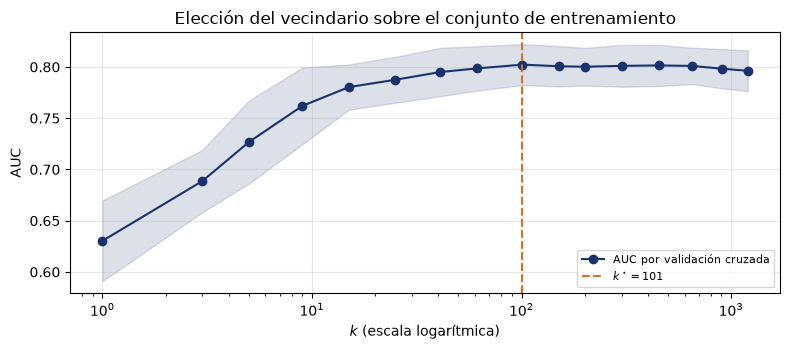

In [9]:
# VERIFICACIÓN — la búsqueda recorrió la rejilla y el escalador quedó dentro del pipeline
busqueda = buscar_k(X_ent, y_ent, REJILLA_K)
k_estrella = busqueda.best_params_["knn__n_neighbors"]

assert isinstance(busqueda.best_estimator_, Pipeline), "el estimador tiene que ser un Pipeline"
assert len(busqueda.cv_results_["mean_test_score"]) == len(REJILLA_K)

auc_vc = busqueda.cv_results_["mean_test_score"]
de_vc = busqueda.cv_results_["std_test_score"]

print(f"{'k':>6}  {'AUC (VC)':>9}  {'DE':>7}")
for k, a, e in zip(REJILLA_K, auc_vc, de_vc):
    marca = "  <- máximo" if k == k_estrella else ""
    print(f"{k:6d}  {a:9.4f}  {e:7.4f}{marca}")

print(f"\nk* = {k_estrella}, que es el {100 * k_estrella / len(y_ent):.1f} % del conjunto "
      f"de entrenamiento")

fig, ax = plt.subplots()
ax.semilogx(REJILLA_K, auc_vc, "o-", color=AZUL, label="AUC por validación cruzada")
ax.fill_between(REJILLA_K, auc_vc - de_vc, auc_vc + de_vc, color=AZUL, alpha=0.15)
ax.axvline(k_estrella, color=NARANJA, ls="--", label=f"$k^\\star = {k_estrella}$")
ax.set_xlabel("$k$ (escala logarítmica)")
ax.set_ylabel("AUC")
ax.set_title("Elección del vecindario sobre el conjunto de entrenamiento")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

### DECIDE

En este conjunto el $21{,}8\ \%$ de las solicitudes incumple. La regla trivial que predice
siempre «no incumple» acierta, por lo tanto, el $78{,}2\ \%$ de las veces.

**¿Con qué medida corresponde elegir $k$ y comparar los modelos: exactitud o AUC?** La
respuesta tiene que decir qué le pasaría a la elección de $k$ con la otra medida.

**Respuesta:** 

Corresponde elegir $k$ mediante AUC. Como solamente el $21.8\%$
incumple, la exactitud con umbral $0.5$ premia fuertemente predecir la clase
mayoritaria y puede elegir un $k$ excesivamente grande que produzca probabilidades
muy parecidas a la tasa base. El AUC evalúa la capacidad de ordenar solicitudes por
riesgo sin depender de ese umbral. Después se puede elegir el umbral según el costo
de falsos positivos y falsos negativos.

---

# 3. La línea base lineal

Un resultado de k-NN no se interpreta solo. La pregunta nunca es «¿cuánto acierta?» sino
«¿cuánto acierta **comparado con qué**?», y la comparación solo es informativa si el otro
modelo ve exactamente los mismos datos preparados de la misma manera. Por eso la línea base
se arma con **el mismo `ColumnTransformer`**: lo que quede de diferencia es atribuible al
método, no al tratamiento previo.

La línea base es la regresión logística de la clase 5. Su frontera es un hiperplano: no
puede curvarse, y en el conjunto de los anillos del laboratorio no llegaba a la mitad. Acá
la situación es otra.

### Ejercicio 3 — El modelo lineal de control

Corresponde armar el `Pipeline` de la regresión logística, con la misma preparación que el
k-NN, y ajustarlo sobre el conjunto de entrenamiento.

In [10]:
def linea_base(X_ent: pd.DataFrame, y_ent: np.ndarray) -> Pipeline:
    modelo = Pipeline([
        ("prep", preparacion(X_ent)),
        ("logistica", LogisticRegression(max_iter=2000)),
    ])
    return modelo.fit(X_ent, y_ent)

In [11]:
# VERIFICACIÓN — los dos modelos ven la misma matriz de atributos
logistica = linea_base(X_ent, y_ent)

cols_knn = busqueda.best_estimator_.named_steps["prep"].get_feature_names_out()
cols_log = logistica.named_steps["prep"].get_feature_names_out()
assert list(cols_knn) == list(cols_log), "los dos modelos no ven las mismas columnas"
print(f"los dos modelos ven las mismas {len(cols_log)} columnas")


def medir(modelo, nombre: str) -> dict:
    """Exactitud y AUC sobre el conjunto de prueba."""
    puntaje = modelo.predict_proba(X_pru)[:, 1]
    return {"modelo": nombre,
            "exactitud": accuracy_score(y_pru, modelo.predict(X_pru)),
            "AUC": roc_auc_score(y_pru, puntaje)}


trivial = {"modelo": "regla trivial (nadie incumple)",
           "exactitud": 1 - y_pru.mean(), "AUC": 0.5}

tabla = pd.DataFrame([
    medir(busqueda.best_estimator_, f"k-NN, k = {k_estrella}"),
    medir(logistica, "regresión logística"),
    trivial,
]).set_index("modelo").round(4)

print("\nConjunto de prueba, sin tocar hasta acá:")
print(tabla.to_string())

los dos modelos ven las mismas 12 columnas

Conjunto de prueba, sin tocar hasta acá:
                                exactitud     AUC
modelo                                           
k-NN, k = 101                       0.812  0.8089
regresión logística                 0.830  0.8162
regla trivial (nadie incumple)      0.782  0.5000


In [12]:
# El escalado, en el mismo problema: k-NN con los atributos numéricos sin estandarizar
sin_escalar = Pipeline([
    ("prep", ColumnTransformer([
        ("num", "passthrough", list(X_ent.select_dtypes("number").columns)),
        ("cat", OneHotEncoder(sparse_output=False), ["historial_crediticio"])])),
    ("knn", KNeighborsClassifier(n_neighbors=k_estrella)),
]).fit(X_ent, y_ent)

auc_con = roc_auc_score(y_pru, busqueda.best_estimator_.predict_proba(X_pru)[:, 1])
auc_sin = roc_auc_score(y_pru, sin_escalar.predict_proba(X_pru)[:, 1])

print(f"k-NN con estandarización : AUC {auc_con:.4f}")
print(f"k-NN sin estandarización : AUC {auc_sin:.4f}")
print(f"la diferencia es de {auc_con - auc_sin:.4f} de AUC, con los mismos datos y el mismo k")

escalas = X_ent.select_dtypes("number").std().sort_values(ascending=False)
print("\nsin estandarizar, cada columna entra en la suma con sus propias unidades:")
print(escalas.round(4).to_string())
print(f"\nla columna de mayor dispersión ({escalas.index[0]}) tiene un desvío "
      f"{escalas.iloc[0] / escalas.iloc[-1]:,.0f} veces mayor que la de menor "
      f"({escalas.index[-1]}): la distancia la decide ella sola.")

k-NN con estandarización : AUC 0.8089
k-NN sin estandarización : AUC 0.7442
la diferencia es de 0.0647 de AUC, con los mismos datos y el mismo k

sin estandarizar, cada columna entra en la suma con sus propias unidades:
monto_solicitado_usd        11065.1988
ingreso_mensual_usd          1202.5516
cuota_mensual_usd             433.1761
plazo_meses                    14.3690
edad_anios                     10.2127
antiguedad_laboral_anios        3.6738
consultas_buro_12m              1.5658
tiene_garantia                  0.4710
cuota_ingreso                   0.1544

la columna de mayor dispersión (monto_solicitado_usd) tiene un desvío 71,676 veces mayor que la de menor (cuota_ingreso): la distancia la decide ella sola.


### Para analizar

1. El $k$ elegido por validación cruzada es enorme: cientos de vecinos, un porcentaje
   apreciable del conjunto de entrenamiento. **¿Qué dice ese valor sobre la forma de la
   frontera del problema?** Conviene contrastarlo con el $k$ que el laboratorio de la clase
   eligió sobre los anillos.
2. La línea base lineal queda por encima del k-NN, y no por poco. **¿Por qué el método que
   puede producir cualquier frontera pierde contra el que solo puede producir un
   hiperplano?** La respuesta tiene que hablar de la varianza del estimador local con
   $p=12$ y $n=3000$, no de la flexibilidad.
3. En exactitud, el k-NN queda apenas por encima de la regla trivial mientras su AUC es
   claramente mayor que $0{,}5$. **¿Cómo se explica esa combinación**, y qué habría que
   cambiar para que la exactitud reflejara lo que el AUC muestra?
4. **¿Qué habría que observar en un problema nuevo para sospechar, antes de ajustar nada,
   que k-NN va a quedar por debajo de un modelo lineal?**

**Respuesta:**

1. El valor elegido, $k=101$, indica que la frontera es suave: conviene promediar
   muchas observaciones y reducir varianza. En los anillos se necesita un vecindario
   más local para seguir una frontera curva.
2. Que k-NN sea más flexible no implica que estime mejor. Con 12 dimensiones y
   3000 observaciones, los vecinos están relativamente lejos y el promedio local
   tiene varianza. La regresión logística aprovecha que la estructura es
   aproximadamente lineal y estima muchos menos parámetros efectivos.
3. k-NN obtiene exactitud $0.8120$, apenas por encima del $0.7820$ trivial, pero AUC
   $0.8089$. Esto significa que ordena razonablemente bien el riesgo aunque el
   umbral $0.5$ clasifique pocos positivos. Hay que elegir otro umbral usando
   validación y los costos del problema.
4. Sospecharía que gana el modelo lineal si la relación es suave y casi aditiva, hay
   muchas dimensiones respecto de las observaciones, existen atributos ruidosos y
   no se observa una frontera local claramente curva.


---

# Conclusión

**El entregable de esta práctica es esta conclusión.** Corresponde escribir tres o cuatro
líneas que respondan, con las cifras producidas arriba, a la pregunta con la que abre el
notebook: qué le pasa a k-NN cuando la estructura del problema es lineal, y qué decisión
tomar frente a un problema de este tipo.

**Conclusión:** 

En este problema de estructura aproximadamente lineal, la regresión
logística supera a k-NN: alcanza AUC $0.8162$ y exactitud $0.8300$, frente a $0.8089$
y $0.8120$ de k-NN con $k=101$. La flexibilidad local no compensa la varianza de
buscar vecinos en 12 dimensiones. Elegiría la regresión logística por su mejor
desempeño, simplicidad e interpretabilidad.

## Para seguir explorando

Fuera del tiempo de clase, y sin evaluación:

1. **El nivel descartado.** Repetir el ajuste con `OneHotEncoder(drop="first")` y con las
   indicadoras estandarizadas, y medir el AUC de cada variante por validación cruzada. Las
   tres codificaciones dicen cosas distintas sobre qué niveles se parecen entre sí; la
   medición dice cuánto cuesta cada afirmación en este conjunto.
2. **Un atributo categórico de alta cardinalidad.** Agregar al conjunto una columna
   artificial con $50$ niveles asignados al azar con semilla fija, codificarla con
   indicadoras y medir cuánto cae el AUC de k-NN y cuánto el de la logística. Es el
   experimento de los atributos de ruido del laboratorio, con la variante categórica.
3. **La distancia de Manhattan.** `KNeighborsClassifier(metric="manhattan")` mantiene la
   equidistancia entre niveles —la codificación indicadora es la misma distancia de Hamming
   en las dos métricas— pero cambia cómo entran las columnas numéricas. Medir si el orden
   entre los dos modelos se sostiene.